In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()
# AT - Temperature
# V - Vaccum
# AP - pressure
# RH - humidity

# PE - Produced_Energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [9]:
df.shape

(9568, 5)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [19]:
# Tensors are the pytorch core Data Structure like arrays in the numpy
import torch
import torch.nn as nn # Includes layers, activation functions etc
# Tensor stored on the RAM
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [20]:
type(X_train_scaled)

numpy.ndarray

In [21]:
type(y_train)
# To access the values directly from the pandas series we use .values

pandas.core.series.Series

In [22]:
y_train.shape
# Invalid shape, due to this we use view(-1, 1), sutable for the tensors

(7654,)

In [23]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset =TensorDataset(X_train_tensor, y_train_tensor) # TensorDataset(In_Features, Out_Features)
test_dataset =TensorDataset(X_test_tensor, y_test_tensor)

In [24]:
# Create DATALOADER
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

## DeepLearning

In [30]:
# ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6), # (In_Features, Out_Features)
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)
        

In [33]:
import torch.optim as optim

model = ANN()

# loss function, optimizer
criterian = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [38]:
# Train ANN
train_losses=[]
val_losses=[]
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb is features of 1 batch
        # yb is labels of 1 batch

        optimizer.zero_grad()
        outputs = model(xb) # forward Propagation----predicted output
        loss = criterian(outputs, yb) # compute loss---(loss for one batch)
        loss.backward() # backward propagation------compute gradient
        optimizer.step() # params Update
        running_loss += loss.item() # loss is a tensor value converted to the python float value (for all batch)
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterian(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {running_val_loss}")

epoch 1/100 ==> train loss = 19.59378395875295 & val loss = 1086.8341064453125
epoch 2/100 ==> train loss = 19.39810993671417 & val loss = 1070.947509765625
epoch 3/100 ==> train loss = 19.739084883530936 & val loss = 1069.8726806640625
epoch 4/100 ==> train loss = 19.670316543181738 & val loss = 1069.953369140625
epoch 5/100 ==> train loss = 19.6780686100324 & val loss = 1053.83935546875
epoch 6/100 ==> train loss = 19.781502962112427 & val loss = 1095.9583740234375
epoch 7/100 ==> train loss = 19.6948217968146 & val loss = 1087.1458740234375
epoch 8/100 ==> train loss = 19.597221370538076 & val loss = 1059.776611328125
epoch 9/100 ==> train loss = 19.737192126115165 & val loss = 1102.2706298828125
epoch 10/100 ==> train loss = 19.561783534288406 & val loss = 1109.10302734375
epoch 11/100 ==> train loss = 19.518869443237783 & val loss = 1090.4014892578125
epoch 12/100 ==> train loss = 19.56607796152433 & val loss = 1090.059814453125
epoch 13/100 ==> train loss = 19.63881516456604 & va

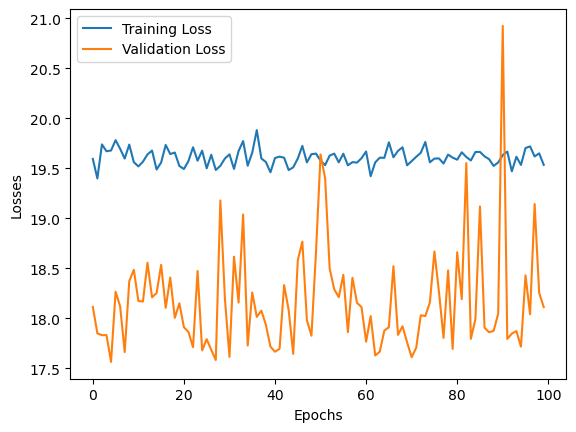

In [39]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()